In [1]:
# Building a MLP to improve Makemore (formalated based as proposed here : https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# read all the names form names.txt
words = open("names.txt", 'r').read().splitlines()

In [4]:
len(words)

32033

In [5]:
# building the vocabulary

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
print(itos)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [63]:
# building the dataset

block_size = 3 # context length
X, Y = [], []
for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w +'.' :
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [248]:
def build_dataset(words):
    block_size = 3 # context length
    X, Y = [], []
    for w in words:
    
        # print(w)
        context = [0] * block_size
        for ch in w +'.' :
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [264]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182580, 3]), torch.int64, torch.Size([182580]), torch.int64)

In [319]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g, requires_grad=True)
W1 = torch.randn((30, 200), generator=g, requires_grad=True)
b1 = torch.randn(200, generator=g, requires_grad=True)
W2 = torch.randn((200, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [320]:
sum(p.nelement() for p in parameters) # num parameters in total

11897

In [321]:
lri =[]
lossi = []
stepi = []

In [322]:
# We can't directly do emb @ W1 + b, as emb.shape = (32, 3, 2) not (32, 6) 
# as eazy way to do this is to use torch.view and give it emb and 
# a viewable shape (total # multiply to be same) for eg (32, 6)

# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape
# torch.cat(torch.unbind(emb, 1), 1).shape

# we use view, very efficient as well ( -1, python will inffer what to put)

for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # [-1, 1] due to tanh
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # nll = -prob[torch.arange(32), Y].log().mean()  # iterate using arange and pick the Y'th column
    loss = F.cross_entropy(logits, Ytr[ix]) 
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())

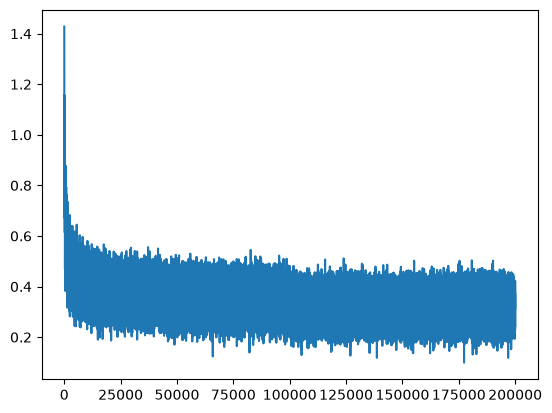

In [323]:
plt.plot(stepi, lossi)

In [324]:
# loss on dev split

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (100, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1614, grad_fn=<NllLossBackward0>)

In [325]:
# loss on training split

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (100, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1179, grad_fn=<NllLossBackward0>)

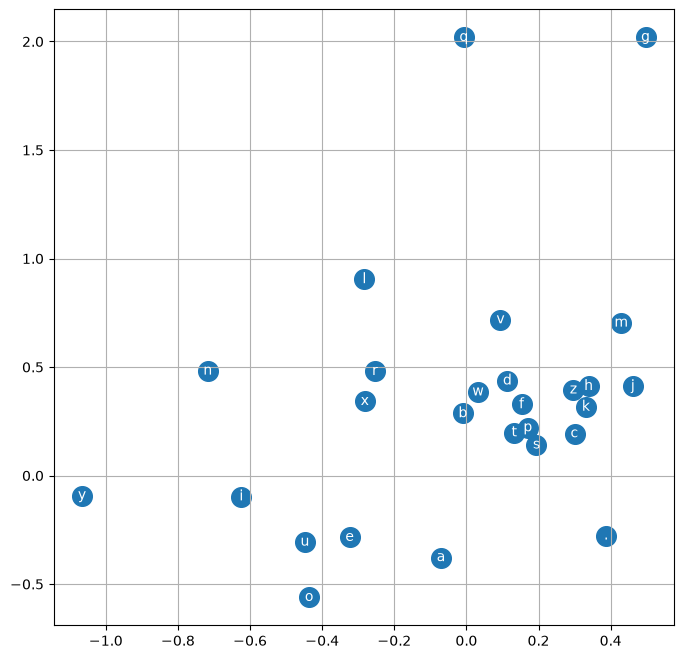

In [295]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# it is much better to have approximate gradients( using minibatches) and have more steps then
# have exact gradient (process whole) with fewer steps

In [290]:
## improvements

# 1. because the model can overfit the data it's trained on, we split our original dataset
# training split, dev/validation split, test split
# 80%, 10%, 10%

# 2. if the dev or test loss are equal to training loss, then we are likely underfitting 
# i.e. we can lower our loss by increasing the networn parameters (scaling)


# 3. might be usefull to scale up the embedding size of 27 char from 2 dim to higher

In [329]:
# sampling 
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  # all .'s
    while True:
        emb = C[torch.tensor([context])] # (1, block_size , d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmah.
amorie.
khy.
milialaty.
salaysleer.
hutt.
den.
rha.
kaeli.
ner.
kia.
chaiivon.
legg.
halm.
joce.
quinn.
shoine.
livani.
wajerrgiefrynix.
kaellinsley.
